In [64]:
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_notebook import *
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
%matplotlib inline

n_samples_test = 10000
experiment_name = 'base_model_10'
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=0, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split='test')
original_data = test_samples[frozenset(modules)]

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [65]:
with total_silence():
    global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name =\
          get_modules_data_from_exp(
              experiment_name=experiment_name,
              n_samples_test=n_samples_test,
              split='test',
              checkpoint_epoch=0)

    objects = get_objects_from_v_latents(
        latent_domains,
        gw_mod,
        global_workspace,
        modules_name,
        modality_from='attr',
        modality_through='color',
        modality_main=['attr'],
        modality_add='color',
        start_v=False
)

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']

    cats = cat.argmax(dim=1).detach().cpu().numpy()


In [66]:
import colorsys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def get_raw_color_values(color_input):
    if torch.is_tensor(color_input):
        color_input = color_input.detach().cpu().numpy()
    color_input = np.clip((color_input + 1) / 2, 0, 1)
    return color_input


def cross_modal_retrieval_color_association(g1, g2, cats, color_rgb, n_hue_bins=8, k=5):
    """
    g1      : (N, D) reprs GW 
    g2      : (N, D) reprs GW 
    cats      : (N,) catégorie de chaque exemple g1
    color_rgb : (N, 3) couleur RGB brute correspondant à g2
    k         : nombre de voisins

    Retourne :
      - category_color_matrix : (n_cat, n_hue_bins), proportions
      - association_strength  : dict {categorie: score 0-1}, 1 = très biaisé vers 1 couleur
      - _hues, _topk_idx      : gardés pour la viz continue (plot_continuous_hue_distribution)
    """
    g1 = torch.as_tensor(g1, dtype=torch.float32)
    g2 = torch.as_tensor(g2, dtype=torch.float32)
    cats = np.asarray(cats)
    v_norm = F.normalize(g1, dim=1)
    c_norm = F.normalize(g2, dim=1)
    sim_matrix = v_norm @ c_norm.T          # (N, N)
    
    topk_idx = sim_matrix.topk(k, dim=1).indices.cpu().numpy()   # (N, k)
    hues = np.array([colorsys.rgb_to_hsv(*rgb)[0] for rgb in color_rgb])
    bin_edges = np.linspace(0, 1, n_hue_bins + 1)
    hue_bins = np.digitize(hues, bin_edges[1:-1])   # (N,) label de couleur par exemple
    retrieved_labels = hue_bins[topk_idx]   # (N, k)
    
    classes = np.unique(cats)
    category_color_matrix = np.zeros((len(classes), n_hue_bins))
    association_strength = {}
    for ci, c in enumerate(classes):
        mask = cats == c
        labels_for_cat = retrieved_labels[mask].ravel()
        counts = np.bincount(labels_for_cat, minlength=n_hue_bins)
        proportions = counts / counts.sum()
        category_color_matrix[ci] = proportions
        association_strength[c] = float(proportions.max() - 1 / n_hue_bins)
    
    return {
        "category_color_matrix": category_color_matrix,
        "association_strength": association_strength,
        "classes": classes,
        "_hues": hues,
        "_topk_idx": topk_idx,
    }

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def plot_hue_histogram(assoc_result, cats, k, n_bins=8,n_cols=3, figsize_per_plot=3.5, save_path=None):
    hues = assoc_result["_hues"]
    topk_idx = assoc_result["_topk_idx"]
    classes = assoc_result["classes"]
    cats = np.asarray(cats)

    retrieved_hues = hues[topk_idx]  # (N, k), dans [0, 1)

    n_classes = len(classes)
    n_cols = min(n_cols, n_classes)
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(figsize_per_plot * n_cols, figsize_per_plot * 0.75 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    bin_colors = [mcolors.hsv_to_rgb((h, 0.8, 0.9)) for h in bin_centers]

    for ci, c in enumerate(classes):
        ax = axes[ci]
        mask = cats == c
        h_cat = retrieved_hues[mask].ravel()

        counts, _ = np.histogram(h_cat, bins=bin_edges)
        ax.bar(bin_centers, counts / (mask.sum()*k), width=bin_width * 0.95,
               color=bin_colors, edgecolor="white", linewidth=0.3)

        ax.axhline(1/n_bins, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)  # référence uniforme
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 0.7)
        ax.set_xlabel("hue")
        ax.set_ylabel("densité")
        ax.set_title(f"cat={c}", fontsize=10)

    for ax in axes[n_classes:]:
        ax.axis("off")

    fig.suptitle("Distribution de teinte des couleurs par catégorie", y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
    return fig

{0: 0.4288850931677019, 1: 0.14759011627906976, 2: 0.14726946107784428}


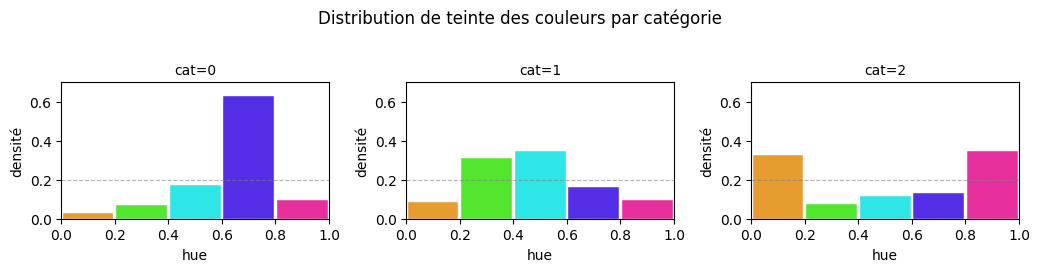

In [68]:
k = 100
colors = get_raw_color_values(original_data['color'])
colors_syn = get_raw_color_values(objects['x2']['color'])
n_bins=5

result = cross_modal_retrieval_color_association(objects['g1']['attr'], objects['g2']['color'], cats, colors_syn, n_hue_bins=n_bins, k=k)
plot_hue_histogram(result, cats, k=k, n_bins=n_bins)
print(result['association_strength'])


In [69]:
result

{'category_color_matrix': array([[0.03079503, 0.07218634, 0.17148137, 0.62888509, 0.09665217],
        [0.08668314, 0.30938081, 0.34759012, 0.161125  , 0.09522093],
        [0.32826946, 0.07682335, 0.11717964, 0.13045808, 0.34726946]]),
 'association_strength': {0: 0.4288850931677019,
  1: 0.14759011627906976,
  2: 0.14726946107784428},
 'classes': array([0, 1, 2]),
 '_hues': array([0.88106281, 0.05899963, 0.91632322, ..., 0.57700486, 0.98719704,
        0.91872488]),
 '_topk_idx': array([[ 347, 2028, 5170, ..., 9649, 5840, 6797],
        [9247,  704,  584, ..., 1383, 5963, 5065],
        [7245, 5645,  769, ..., 8726, 7964, 6031],
        ...,
        [8398, 2481, 2597, ..., 2626, 8893, 8155],
        [ 116, 2911, 1312, ..., 2165, 9475, 3959],
        [3566, 3921, 7045, ..., 2546, 2819, 3750]])}

In [70]:
def cross_modal_retrieval_color_association_lda(
    g1, g2, cats, color_rgb, k=5, cat_names=None
):
    """
    g1, g2    : (N, D) reprs GW
    cats      : (N,) catégorie de chaque exemple g1
    color_rgb : (N, 3) couleur RGB brute correspondant à g2
    k         : nombre de voisins retrouvés

    Retourne :
      - association_strength : dict {categorie: score}, recall LDA - chance
      - kruskal_H, kruskal_p : séparabilité globale des distributions de teinte
      - lda_score            : accuracy globale du LDA (toutes catégories)
      - per_cat              : {cat: {'mean_hue', 'std_hue', 'name'}}
      - classes, _hues, _topk_idx : gardés pour la viz
    """
    g1 = torch.as_tensor(g1, dtype=torch.float32)
    g2 = torch.as_tensor(g2, dtype=torch.float32)
    cats = np.asarray(cats)
    color_rgb = np.asarray(color_rgb)

    v_norm = F.normalize(g1, dim=1)
    c_norm = F.normalize(g2, dim=1)
    sim_matrix = v_norm @ c_norm.T
    topk_idx = sim_matrix.topk(k, dim=1).indices.cpu().numpy()  # (N, k)

    # couleurs retrouvées par top-k, associées à la catégorie de la requête
    retrieved_colors = color_rgb[topk_idx].reshape(-1, 3)   # (N*k, 3)
    retrieved_cats = np.repeat(cats, k)                     # (N*k,)

    # stats globales via la fonction existante (Kruskal, LDA score, per_cat)
    metrics, fig = hue_analysis(retrieved_colors, retrieved_cats)
    hues = metrics['hues']

    return metrics, fig

In [74]:
metrics, fig = cross_modal_retrieval_color_association_lda(objects['g1']['attr'], objects['g2']['color'], cats, colors_syn, k=1)


In [75]:
metrics

{'kruskal_H': 2143.6057561444727,
 'kruskal_p': 0.0,
 'lda_score': 0.644,
 'per_cat': {0: {'name': 'Cat. 0',
   'mean_hue': 238.37453798120467,
   'std_hue': 61.90434328214206},
  1: {'name': 'Cat. 1',
   'mean_hue': 153.58038359470657,
   'std_hue': 74.12670037275409},
  2: {'name': 'Cat. 2',
   'mean_hue': 347.4490074423453,
   'std_hue': 72.70980655614039}},
 'hues': array([290.47165341,  12.7465392 , 336.19768688, ..., 146.71573198,
        257.16897694, 339.13166992]),
 'labels': array([2, 2, 2, ..., 0, 2, 2])}

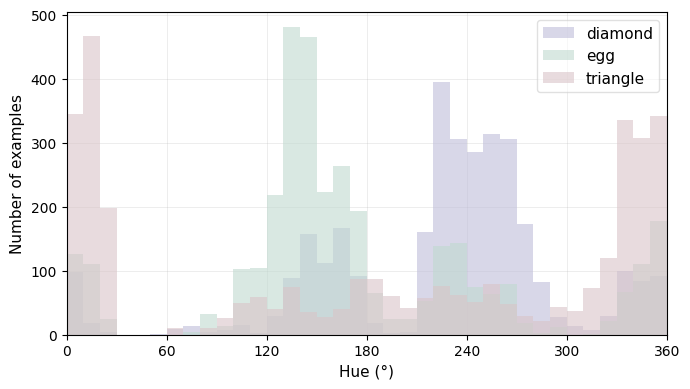

In [76]:
display(fig)